In [38]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pymoo.indicators.hv import Hypervolume
import score.envs as envs
import itertools

In [30]:
env_id = "SCORE-MO-CEBAF-8D-VEC-TF"
# env_id = "SCORE-MO-CEBAF-N-VEC-TF-v0"
env = envs.make(env_id)
ref = [env.linac.max_allowed_heat, env.linac.max_allowed_trip]
if "-8D-" in env_id:
    ideal = [20.0, 0.01]
    mobo_nsteps = 140
elif "-N-" in env_id:
    ideal = [2380.0, 1.0]
    mobo_nsteps = 1000
energy_bound = [env.min_energy, env.max_energy]

Attempting to load score.envs with mo_cebaf_env
####################################
Using action mode:  direct
####################################
Env Name:  1l10_test8
Cavity Ids:  ['1L10-1' '1L10-2' '1L10-3' '1L10-4' '1L10-5' '1L10-6' '1L10-7' '1L10-8']
Lengths:  tf.Tensor([0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5], shape=(8,), dtype=float32)
types:  ['C25' 'C25' 'C25' 'C25' 'C25' 'C25' 'C25' 'C25']
max_gset_to_use:  [5.75 9.   9.2  6.   4.   7.6  6.6  8.2 ]
min grad:  tf.Tensor([3. 3. 3. 3. 3. 3. 3. 3.], shape=(8,), dtype=float32)
Q0s:  tf.Tensor([5.21e+09 5.00e+09 6.82e+09 4.77e+09 5.31e+09 5.32e+09 2.60e+09 3.92e+09], shape=(8,), dtype=float32)
Trip slopes:  tf.Tensor([1.301 1.485 1.942 1.911 0.487 1.519 2.788 1.339], shape=(8,), dtype=float32)
Trip Offset:  tf.Tensor([9.328 8.724 8.845 5.679 9.528 8.108 6.389 7.684], shape=(8,), dtype=float32)
Initial gradients:  tf.Tensor([[5.75 9.   9.2  6.   4.   7.6  6.6  8.2 ]], shape=(1, 8), dtype=float32)
Requred energy mean:  20.08   with allowe

In [31]:
def calculate_hv(heat, trip, ref, ideal):
    metric = Hypervolume(ref_point= ref,
                         norm_ref_point=False,
                         zero_to_one=False,
                         ideal=ideal,
                         nadir=ref)
    max_vol = (ref[0] - ideal[0]) * (ref[1] - ideal[1])
    good_indices = np.where((heat <= ref[0]) & (trip <= ref[1]))[0]
    
    # If no points are below reference, return hypervolume as 0.
    if good_indices.shape[0] <= 0:
        return 0.
    heat, trip = heat[good_indices], trip[good_indices]
    results = np.stack([heat, trip], axis=1)
    
    return np.round(metric.do(results)*100/max_vol, 3)
    

In [79]:
def read_results(path, energy_min, energy_max, start, end, interval, ref, ideal):
    heat, trip, time, step_time = [], [], [], []
    hv_list = []
    for i in range(start, end, interval):
        filename = "inference_results_"+str(i).zfill(6)+".pkl"
        result_dict = np.load(os.path.join(path, filename), allow_pickle=True)
        h = np.array(result_dict["heat"])
        t = np.array(result_dict["trip"])
        if "MOBO" in path:
            energy = np.array(result_dict["energy"])
            good_indices = np.where((energy <= energy_max) & (energy >= energy_min))[0]
            h = h[good_indices]
            t = t[good_indices]
        heat.append(h)
        trip.append(t)
        step_time.append(result_dict["step_time"])
        time.append(result_dict["t_elapsed"])
        hv_list.append(calculate_hv(h, t, ref, ideal))
    return heat, trip, np.array(time), np.array(step_time), hv_list

In [80]:
if "-8D-" in env_id:
    mobo_path = "../results/MOO_paper_study_v2/MOBO/"
    moga_path = "../results/MOO_paper_study_v2/MOGA/"
    ddrl_path = "../results/MOO_paper_study_v2/DDRL/"
    motd3_path = None
else:
    mobo_path = "../results/MOO_paper_study_v2/MOBO_North/"
    moga_path = "../results/MOO_paper_study_v2/MOGA_North/"
    ddrl_path = "../results/MOO_paper_study_v2/DDRL_North/"
    motd3_path = None

In [81]:
path_list = [moga_path, ddrl_path, mobo_path, motd3_path]
label_list = ["MOGA", "DDRL", "MOBO", "MOTD3"]
colors = ["#FFAA00", "#00B000", "#E9002D", "black"]

In [82]:
mobo_heat_list, mobo_trip_list, mobo_time_list, mobo_hv_list = [], [], [], [] 
for i in range(1, 17):
    full_path = os.path.join(mobo_path, "trial_"+str(i))
    heat, trip, time, step_time, hv = read_results(full_path, energy_bound[0], energy_bound[1], 0, mobo_nsteps, 1, ref, ideal)
    mobo_heat_list.append(heat)
    mobo_trip_list.append(trip)
    mobo_time_list.append(time)
    mobo_hv_list.append(hv)

In [53]:
# padded = np.array(list(zip(*itertools.zip_longest(*x, fillvalue=0))))
# max_length = max([len(x) for x in mobo_heat_list])
# print(max_length)
# mobo_heat_list_padded = np.zeros((17, max_length, 8))
# mobo_trip_list_padded = np.zeros((17, max_length, 8))
# mobo_time
# mobo_heat_list = list(zip(*itertools.zip_longest(*mobo_heat_list, fillvalue=np.zeros(8))))
# mobo_trip_list = list(zip(*itertools.zip_longest(*mobo_trip_list, fillvalue=np.zeros(8))))
# mobo_time_list = list(zip(*itertools.zip_longest(*mobo_time_list, fillvalue=np.zeros(8))))
# mobo_hv_list = list(zip(*itertools.zip_longest(*mobo_hv_list, fillvalue=np.zeros(8))))

In [63]:
# mobo_hv_padded = np.array(list(zip(*itertools.zip_longest(*mobo_hv_list, fillvalue=0))))
# mobo_time_padded = np.array(list(zip(*itertools.zip_longest(*mobo_time_list, fillvalue=0))))

In [ ]:
ddrl_heat_list, ddrl_trip_list, ddrl_time_list, ddrl_hv_list = [], [], [], [] 
for i in range(1, 16):
    full_path = os.path.join(ddrl_path, "trial_"+str(i))
    heat, trip, time, step_time, hv = read_results(full_path, energy_bound[0], energy_bound[1], 100, 50000, 100, ref, ideal)
    ddrl_heat_list.append(heat)
    ddrl_trip_list.append(trip)
    ddrl_time_list.append(time)
    ddrl_hv_list.append(hv)

In [56]:
moga_heat_list, moga_trip_list, moga_time_list, moga_hv_list = [], [], [], [] 
for i in range(1, 16):
    full_path = os.path.join(moga_path, "trial_"+str(i))
    heat, trip, time, step_time, hv = read_results(full_path, energy_bound[0], energy_bound[1], 100, 50000, 100, ref, ideal)
    moga_heat_list.append(heat)
    moga_trip_list.append(trip)
    moga_time_list.append(time)
    moga_hv_list.append(hv)

In [57]:
def get_hypervolume_comparison(hv_list, time_list, label_list, colors, x_axis="time"):
    for i in range(len(hv_list)):
        print(label_list[i], " Max HV: ", np.max(hv_list[i]))
        hv_mean = np.mean(hv_list[i], axis=0)
        hv_std = np.std(hv_list[i], axis=0)
        time_mean = np.mean(time_list[i], axis=0) / 60.
        time_std = np.std(time_list[i], axis=0) / 60.

        if x_axis == "time":
            x = time_mean
            xerr = time_std
            xlabel = "Time (min)"
        else:
            x = np.arange(len(time_mean))
            if "MOBO" not in label_list[i]:
                x = x*100
            xerr = None
            xlabel = "Steps"
        plt.errorbar(x, hv_mean, yerr=hv_std, xerr=xerr, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=5, elinewidth=2, alpha=0.65)

    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel("Hypervolume (Normalized %)", fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.show()

# get_hypervolume_comparison([mobo_hv_list, moga_hv_list, ddrl_hv_list], [mobo_time_list, moga_time_list, ddrl_time_list], ["MOBO", "MOGA", "DDRL"], colors=["orange", "blue", "red"])
# get_hypervolume_comparison([mobo_hv_list, moga_hv_list, ddrl_hv_list], [mobo_time_list, moga_time_list, ddrl_time_list], ["MOBO", "MOGA", "DDRL"], colors=["orange", "blue", "red"], x_axis="step")

In [58]:
# get_hypervolume_comparison([ddrl_hv_list], [ddrl_time_list], ["DDRL"], colors=["orange", "blue", "red"])
# get_hypervolume_comparison([ddrl_hv_list], [ddrl_time_list], ["DDRL"], colors=["orange", "blue", "red"], x_axis="step")

MOBO  Max HV:  34.135
MOGA  Max HV:  34.769
DDRL  Max HV:  34.499


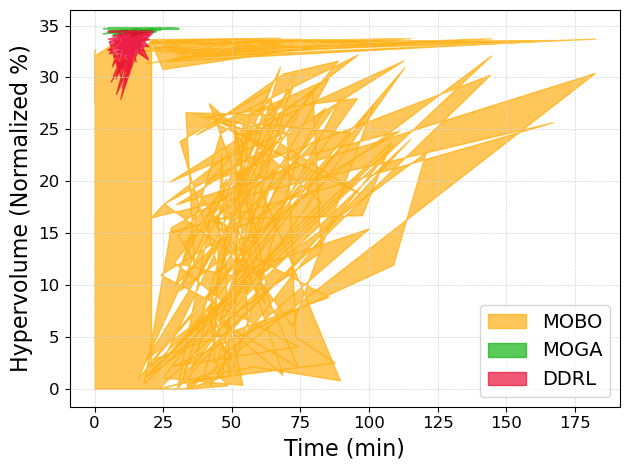

MOBO  Max HV:  34.135
MOGA  Max HV:  34.769
DDRL  Max HV:  34.499


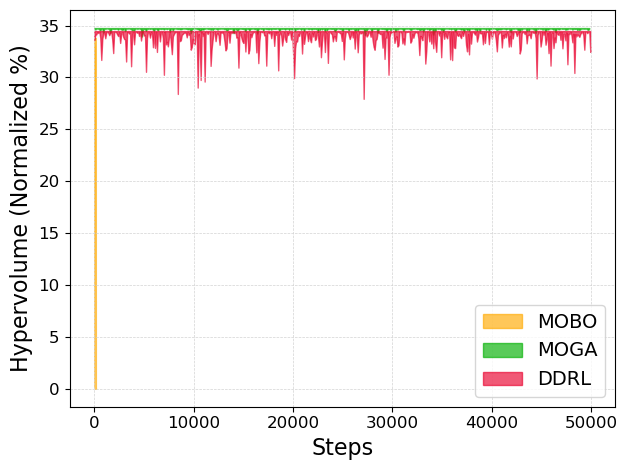

In [73]:
colors = ["#FFAA00", "#00B000", "#E9002D"]
def get_hypervolume_comparison_v2(hv_list, time_list, label_list, colors, x_axis="time", upper_q=0.75, lower_q=0.25, plot_type="area", xlim=None, ylim=None):
    for i in range(len(hv_list)):
        print(label_list[i], " Max HV: ", np.max(hv_list[i]))
        # hv_mean = np.mean(hv_list[i], axis=0)
        # hv_std = np.std(hv_list[i], axis=0)
        # time_mean = np.mean(time_list[i], axis=0) / 60.
        # time_std = np.std(time_list[i], axis=0) / 60.
        hv_median = np.median(hv_list[i], axis=0)
        hv_upper = np.quantile(hv_list[i], q=upper_q, axis=0) - hv_median
        hv_lower = hv_median - np.quantile(hv_list[i], q=lower_q, axis=0)
        time = np.array(time_list[i]) / 60.
        time_median = np.median(time, axis=0)
        time_upper = np.quantile(time, q=upper_q, axis=0) - time_median
        time_lower = time_median - np.quantile(time, q=lower_q, axis=0)

        if x_axis == "time":
            x = time_median
            xerr = np.vstack([time_lower, time_upper])
            xlabel = "Time (min)"
        else:
            x = np.arange(len(time_median))
            if "MOBO" not in label_list[i]:
                x = x*100
            xerr = None
            xlabel = "Steps"
        if plot_type == "area":
            plt.fill_between(x, y1=hv_median-hv_lower, y2=hv_median+hv_upper, label=label_list[i], color=colors[i], alpha=0.65)
            # plt.errorbar(x, hv_median, yerr=np.vstack([hv_lower, hv_upper]), xerr=xerr, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=3, elinewidth=2, alpha=0.65)
        else:
            plt.errorbar(x, hv_median, yerr=np.vstack([hv_lower, hv_upper]), xerr=xerr, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=3, elinewidth=2, alpha=0.65)

    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel("Hypervolume (Normalized %)", fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend(fontsize=14)
    # plt.xscale("log")
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.tight_layout()
    plt.show()

one_sigma_bound = [0.186, 0.814]
two_sigma_bound = [0.023, 0.977]
get_hypervolume_comparison_v2([mobo_hv_padded, moga_hv_list, ddrl_hv_list], [mobo_time_padded, moga_time_list, ddrl_time_list], ["MOBO", "MOGA", "DDRL"], colors=colors, upper_q=one_sigma_bound[1], lower_q=one_sigma_bound[0], xlim=None, ylim=None)
get_hypervolume_comparison_v2([mobo_hv_padded, moga_hv_list, ddrl_hv_list], [mobo_time_padded, moga_time_list, ddrl_time_list], ["MOBO", "MOGA", "DDRL"], colors=colors, x_axis="step", upper_q=one_sigma_bound[1], lower_q=one_sigma_bound[0], xlim=None, ylim=None)

MOBO  Max HV:  34.135
(16, 181)
MOGA  Max HV:  34.769
(15, 499)
DDRL  Max HV:  34.499
(15, 500)


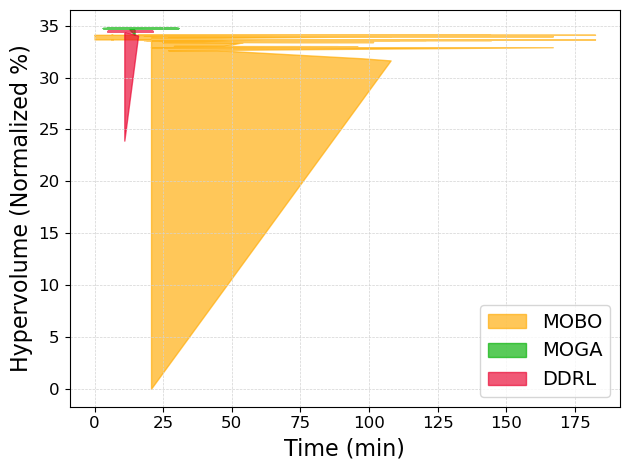

MOBO  Max HV:  34.135
(16, 181)
MOGA  Max HV:  34.769
(15, 499)
DDRL  Max HV:  34.499
(15, 500)


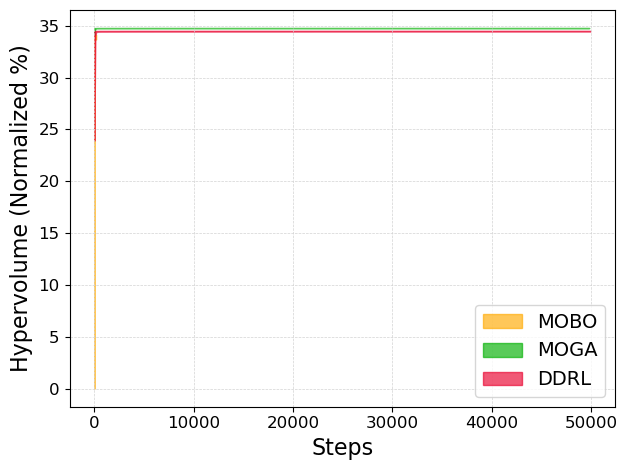

In [74]:
colors = ["#FFAA00", "#00B000", "#E9002D"]
def get_hypervolume_comparison_v3(hv_list, time_list, label_list, colors, x_axis="time", upper_q=0.75, lower_q=0.25, plot_type="area", xlim=None, ylim=None):
    for i in range(len(hv_list)):
        print(label_list[i], " Max HV: ", np.max(hv_list[i]))
        # hv_mean = np.mean(hv_list[i], axis=0)
        # hv_std = np.std(hv_list[i], axis=0)
        # time_mean = np.mean(time_list[i], axis=0) / 60.
        # time_std = np.std(time_list[i], axis=0) / 60.
        hv_cummax_list = np.array([np.maximum.accumulate(X) for X in hv_list[i]])
        print(hv_cummax_list.shape)
        hv_median = np.median(hv_cummax_list, axis=0)
        hv_upper = np.quantile(hv_cummax_list, q=upper_q, axis=0) - hv_median
        hv_lower = hv_median - np.quantile(hv_cummax_list, q=lower_q, axis=0)
        time = np.array(time_list[i]) / 60.
        time_median = np.median(time, axis=0)
        time_upper = np.quantile(time, q=upper_q, axis=0) - time_median
        time_lower = time_median - np.quantile(time, q=lower_q, axis=0)

        if x_axis == "time":
            x = time_median
            xerr = np.vstack([time_lower, time_upper])
            xlabel = "Time (min)"
        else:
            x = np.arange(len(time_median))
            if "MOBO" not in label_list[i]:
                x = x*100
            xerr = None
            xlabel = "Steps"
        if plot_type == "area":
            plt.fill_between(x, y1=hv_median-hv_lower, y2=hv_median+hv_upper, label=label_list[i], color=colors[i], alpha=0.65)
            # plt.errorbar(x, hv_median, yerr=np.vstack([hv_lower, hv_upper]), xerr=xerr, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=3, elinewidth=2, alpha=0.65)
        else:
            plt.errorbar(x, hv_median, yerr=np.vstack([hv_lower, hv_upper]), xerr=xerr, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=3, elinewidth=2, alpha=0.65)

    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel("Hypervolume (Normalized %)", fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend(fontsize=14)
    # plt.xscale("log")
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.tight_layout()
    plt.show()

one_sigma_bound = [0.186, 0.814]
two_sigma_bound = [0.023, 0.977]
get_hypervolume_comparison_v3([mobo_hv_padded, moga_hv_list, ddrl_hv_list], [mobo_time_padded, moga_time_list, ddrl_time_list], ["MOBO", "MOGA", "DDRL"], colors=colors, upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None)
get_hypervolume_comparison_v3([mobo_hv_padded, moga_hv_list, ddrl_hv_list], [mobo_time_padded, moga_time_list, ddrl_time_list], ["MOBO", "MOGA", "DDRL"], colors=colors, x_axis="step", upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None)

In [77]:
from jlab_opt_control.utils.losses import find_pareto_front

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (16,) + inhomogeneous part.

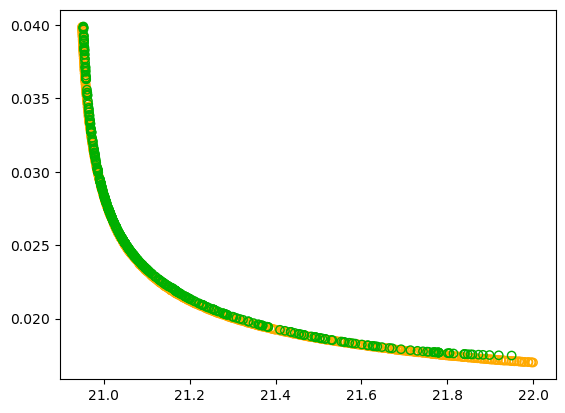

In [78]:
heat_global = [moga_heat_list, ddrl_heat_list, mobo_heat_list]
trip_global = [moga_trip_list, ddrl_trip_list, mobo_trip_list]
hv_global = [moga_hv_list, ddrl_hv_list, mobo_hv_list]
labels_global = ["MOGA", "DDRL", "MOBO"]
colors = ["#FFAA00", "#00B000", "#E9002D"]
t = [1.0, 1.0, 1.0]
for i in range(len(heat_global)):
    # heat_arr = []
    # trip_arr = []
    # for j in range(len(heat_global)):
    #     heat_arr.append(heat_global[i][j][-1])
    #     trip_arr.append(trip_global[i][j][-1])
    # mean_heat = np.mean(heat_arr, axis=0)
    # std_heat = np.mean(trip_arr, axis=0)
    # print(heat_global[i][-1][-1], trip_global[i][-1][-1])
    # break
    best_pareto_indices = np.where(hv_global[i] == np.max(hv_global[i]))
    max_hv = np.round(np.max(hv_global[i]), 2)
    heat = heat_global[i][best_pareto_indices[0][0]][best_pareto_indices[1][0]]
    trip = trip_global[i][best_pareto_indices[0][0]][best_pareto_indices[1][0]]
    if "MOBO" in labels_global[i]:
        results = find_pareto_front(np.stack([heat, trip], axis=1))
        print(results.shape)
        heat, trip = results[:, 0], results[:, 1]
        print(heat.shape)
        facecolor="red"
    else:
        facecolor="none"
    plt.scatter(heat, trip, label=labels_global[i]+" HV: "+str(max_hv), edgecolor=colors[i], alpha=t[i], marker="o", facecolor=facecolor)#, facecolor="none")
plt.legend(fontsize=14)
plt.xlim([20.9, ref[0]])
plt.ylim([0.016, ref[1]])
plt.grid(color="gray", linestyle="--", alpha=0.2)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Heat [W]", fontsize=14)
plt.ylabel("Trip Rate [per hour]", fontsize=14)

In [ ]:
def get_time_evolution(time_list, label_list, colors):
    for i in range(len(time_list)):
        time_mean = np.mean(time_list[i], axis=0)
        time_std = np.std(time_list[i], axis=0)
        
        x = np.arange(len(time_mean))
        if "MOBO" not in label_list[i]:
            x = x * 100

        coeff = np.polyfit(x, time_mean, 2)
        print(coeff)
        fit_x = np.arange(len(time_mean))
        fit_y = coeff[0]*fit_x**2 + coeff[1]*fit_x + coeff[2]
            
        plt.errorbar(x, y=time_mean, yerr=time_std, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=5, elinewidth=2, alpha=0.7)
        # if "MOBO" in label_list[i]:
        #     # plt.plot(x, 0.2*x+(x*0.045)**3, color="black", linestyle='--', label="fit: $0.2x + 0.025*x^3$", linewidth=2)
        #     plt.plot(fit_x, fit_y, color="black", linestyle='--', label="fit: $0.2x + 0.025*x^3$", linewidth=2)
        # if "MOGA" in label_list[i]:
        coeff = np.round(coeff, 3)
        label_str = "fit: $"+str(coeff[0])+"x^2 + "+str(coeff[1])+"x + "+str(coeff[2])+"$"
        plt.plot(fit_x, fit_y, color="black", linestyle='--', label=label_str, linewidth=2)
            
            
        
    plt.xlabel("Steps", fontsize=16)
    plt.ylabel("Time (min)", fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.show()

# get_time_evolution([time_list, ddrl_time_list], ["MOBO (Xopt)", "DDRL"], ["orange", "pink"])
get_time_evolution([mobo_time_list], ["MOBO (Xopt)"], ["#E9002D"])
get_time_evolution([ddrl_time_list], ["DDRL"], ["#00B000"])
get_time_evolution([moga_time_list], ["MOGA"], ["#FFAA00"])
get_time_evolution([mobo_time_list, moga_time_list, ddrl_time_list], ["MOBO (Xopt)", "MOGA", "DDRL"], ["#E9002D", "#FFAA00", "#00B000"])